# Long-term peak parameters


In [14]:
# Importing Python and external packages


import os
import sys
import importlib
from importlib import reload 
from dataclasses import dataclass, field, fields
from itertools import compress
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from cycler import cycler

import fooof
from fooof.plts.spectra import plot_spectrum

import scipy
import scipy.io as sio
from scipy import signal
from scipy.signal import spectrogram, hann, butter, filtfilt, freqz
from scipy import stats

import seaborn as sns
import pingouin as pg
import itertools
from itertools import combinations
from statannotations.Annotator import Annotator
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# import openpyxl
# from openpyxl import Workbook, load_workbook
# import xlrd
import pickle
import json
import csv

#mne
import mne_bids
import mne
from mne.time_frequency import tfr_morlet 

In [15]:
jennifer_user_path = os.getcwd()
while jennifer_user_path[-14:] != 'jenniferbehnke':
    jennifer_user_path = os.path.dirname(jennifer_user_path)

# directory to this Repository
project_path = os.path.join(jennifer_user_path, 'code', 'BetaSenSightLongterm', 'BetaSenSightLongterm')
sys.path.append(project_path)

os.chdir(project_path)

import src.bssu.utils.find_folders as find_folders
importlib.reload(find_folders)

# import PyPerceive

project_path = find_folders.chdir_repository("Py_Perceive")

from PerceiveImport.classes import (
    main_class, modality_class, metadata_class,
    session_class, condition_class, task_class,
    contact_class, run_class
)

import PerceiveImport.methods.load_rawfile as load_rawfile
import PerceiveImport.methods.find_folders as PyPerceive_find_folders
import PerceiveImport.methods.metadata_helpers as metaHelpers

# import meet

project_path = find_folders.chdir_repository("meet")

import meet as meet

# import all functions from BetaSenSightLongterm
project_path = find_folders.chdir_repository("BetaSenSightLongterm")

# tfr, processing
import src.bssu.tfr.BSSuPsd as BSSuPsd
import src.bssu.tfr.FastFourierPSD as FFpsd
import src.bssu.tfr.time_frequency_beta_erd_fooof_fit as tfr_fooof
import src.bssu.tfr.fooof_fit as fooof_fit
import src.bssu.tfr.fooof_peak_analysis as fooof_peaks

# bipolar Channel Analysis
import src.bssu.bipolar.power_spectra_plots as power_spectra_plots
import src.bssu.bipolar.PeakFrequencies_PSD as PeakFrequency_psd
import src.bssu.bipolar.BIP_channelGroups as BIP_channelGroups
import src.bssu.bipolar.BIP_perChannelAnalysis as BIP_perChannel


# monopolar Referencing
import src.bssu.monopolar.MonoRef_JLB as MonoRefJLB
import src.bssu.monopolar.GroupMonopolarPSD as groupMonopol
import src.bssu.monopolar.monoRef_weightPsdAverageByCoordinateDistance as MonoRefWeightedCoordinateDistance

# Ranking Order
import src.bssu.ranking.HighestRankedChannelPSD as highestRank
import src.bssu.ranking.monopolPSDaverage_withinSubject as PSDaverageMonopol
import src.bssu.ranking.BIPchannelGroups_ranks as BIP_ranks
import src.bssu.ranking.Permutation_rankings as Permute_ranks


# Clinical stimulation parameters
import src.bssu.stimulation.activeStimulationContacts as activeStimContacts

# utility functions
import src.bssu.utils.loadResults as loadResults
import src.bssu.utils.find_folders as find_folders
import src.bssu.utils.writeGroupDataframes as writeGroupDF
import src.bssu.utils.percept_helpers as percept_helpers

# import Classes
from src.bssu.classes import (metadataAnalysis_class, mainAnalysis_class, sessionAnalysis_class, 
                              channelAnalysis_class, featureAnalysis_class, frequencyBand_class)

# import mni coordinates
import src.bssu.mni.load_rotated_coordinates as load_mni


importlib.reload(BSSuPsd)
importlib.reload(MonoRefJLB)
importlib.reload(loadResults)
importlib.reload(highestRank)
importlib.reload(groupMonopol)
importlib.reload(PSDaverageMonopol)
importlib.reload(FFpsd)
importlib.reload(find_folders)
importlib.reload(metadataAnalysis_class)
importlib.reload(mainAnalysis_class)
importlib.reload(sessionAnalysis_class)
importlib.reload(channelAnalysis_class)
importlib.reload(featureAnalysis_class)
importlib.reload(frequencyBand_class)
importlib.reload(PeakFrequency_psd)
importlib.reload(power_spectra_plots)
importlib.reload(BIP_channelGroups)
importlib.reload(BIP_ranks)
importlib.reload(activeStimContacts)
importlib.reload(Permute_ranks)
importlib.reload(BIP_perChannel)
importlib.reload(load_mni)
importlib.reload(writeGroupDF)
importlib.reload(tfr_fooof)
importlib.reload(fooof_fit)
importlib.reload(MonoRefWeightedCoordinateDistance)
importlib.reload(fooof_peaks)
importlib.reload(percept_helpers)

<module 'src.bssu.utils.percept_helpers' from '/Users/jenniferbehnke/code/BetaSenSightLongterm/BetaSenSightLongterm/src/bssu/utils/percept_helpers.py'>

In [16]:
# load if you want to see complete Dataframes
pd.set_option("display.max_rows", None)

## Load the CF and power parameters

In [7]:
beta_data = fooof_peaks.calculate_auc_beta_power_fu18or24(
        fooof_spectrum="periodic_spectrum",
        fooof_version="v2",
        highest_beta_session="highest_fu3m",
        around_cf="around_cf_at_fixed_session",
    )

The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate

In [51]:
beta_data["ring"].head()

,subject_hemisphere,session,bipolar_channel,fooof_error,fooof_r_sq,fooof_exponent,fooof_offset,fooof_power_spectrum,periodic_plus_aperiodic_power_log,fooof_periodic_flat,...,low_beta_band_width,high_beta_center_frequency,high_beta_peak_power,high_beta_band_width,round_beta_cf,beta_power_auc,round_high_beta_cf,high_beta_power_auc,round_low_beta_cf,low_beta_power_auc
0,017_Right,3,12,0.07857,0.972904,1.343522,0.757904,"[0.0003292927862230677, 0.0003079802974601531,...","[0.35352735458664525, 0.11698373243642358, -0....","[6.336812502902425e-05, 0.00010218204803303865...",...,NaN,29.434382,1.099716,4.714062,29,2.710997,29,2.710997,NaN,NaN
0,017_Right,12,12,0.073192,0.97929,1.630052,1.241417,"[2.398081733190338e-14, 1.461053500406706e-13,...","[0.7507223128519614, 0.463684361514294, 0.2600...","[1.874458224754675e-15, 2.179651870684689e-14,...",...,NaN,28.747068,0.620417,6.541593,29,0.823918,29,0.823918,NaN,NaN
2,017_Left,3,23,0.060691,0.984825,1.477141,0.813999,"[0.000361940406675032, 0.0005170010807471481, ...","[0.36940200124321204, 0.10939781985683497, -0....","[6.71510727808865e-05, 0.00017456823606811831,...",...,NaN,30.461935,0.555989,6.435033,30,0.440594,30,0.440594,NaN,NaN
2,017_Left,12,23,0.079578,0.962155,1.391419,0.742791,"[0.0025715350157131667, 0.002557549779595769, ...","[0.324461719225958, 0.07984080617177874, -0.09...","[0.0005293948412392593, 0.0009251882586768835,...",...,NaN,23.663613,0.255086,12.324663,30,0.077358,30,0.077358,NaN,NaN
1,019_Right,3,01,0.124968,0.96885,1.419248,0.867746,"[0.1856642791784857, 0.14061256802917677, 0.12...","[0.4688092781872363, 0.22828344469070014, 0.06...","[0.028299334615656334, 0.03769068811808026, 0....",...,3.0,28.498156,1.354711,19.049443,28,7.147768,28,7.147768,18.0,6.827615


## Peak Power difference relative to 3 MFU maximal beta peak

In [39]:
rel_to_3m_data = fooof_peaks.rel_to_3mfu_change_beta_peak_power_or_cf(
    fooof_spectrum="periodic_spectrum",
    fooof_version="v2",
    data_to_analyze="beta_power_auc",
    around_cf="around_cf_at_fixed_session",
)


The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate

In [72]:
rel_to_3m_data.head()

,channel_group,subject_hemisphere,bipolar_channel,session,absolute_beta_power_auc,rel_to_fu3m_beta_power_auc
0,ring,017_Right,12,3,2.710997,0.000000
1,ring,017_Right,12,12,0.823918,-1.887078
2,ring,017_Left,23,3,0.440594,0.000000
3,ring,017_Left,23,12,0.077358,-0.363236
4,ring,019_Right,01,3,7.147768,0.000000


## Plot the relative peak parameters to session 3

The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency

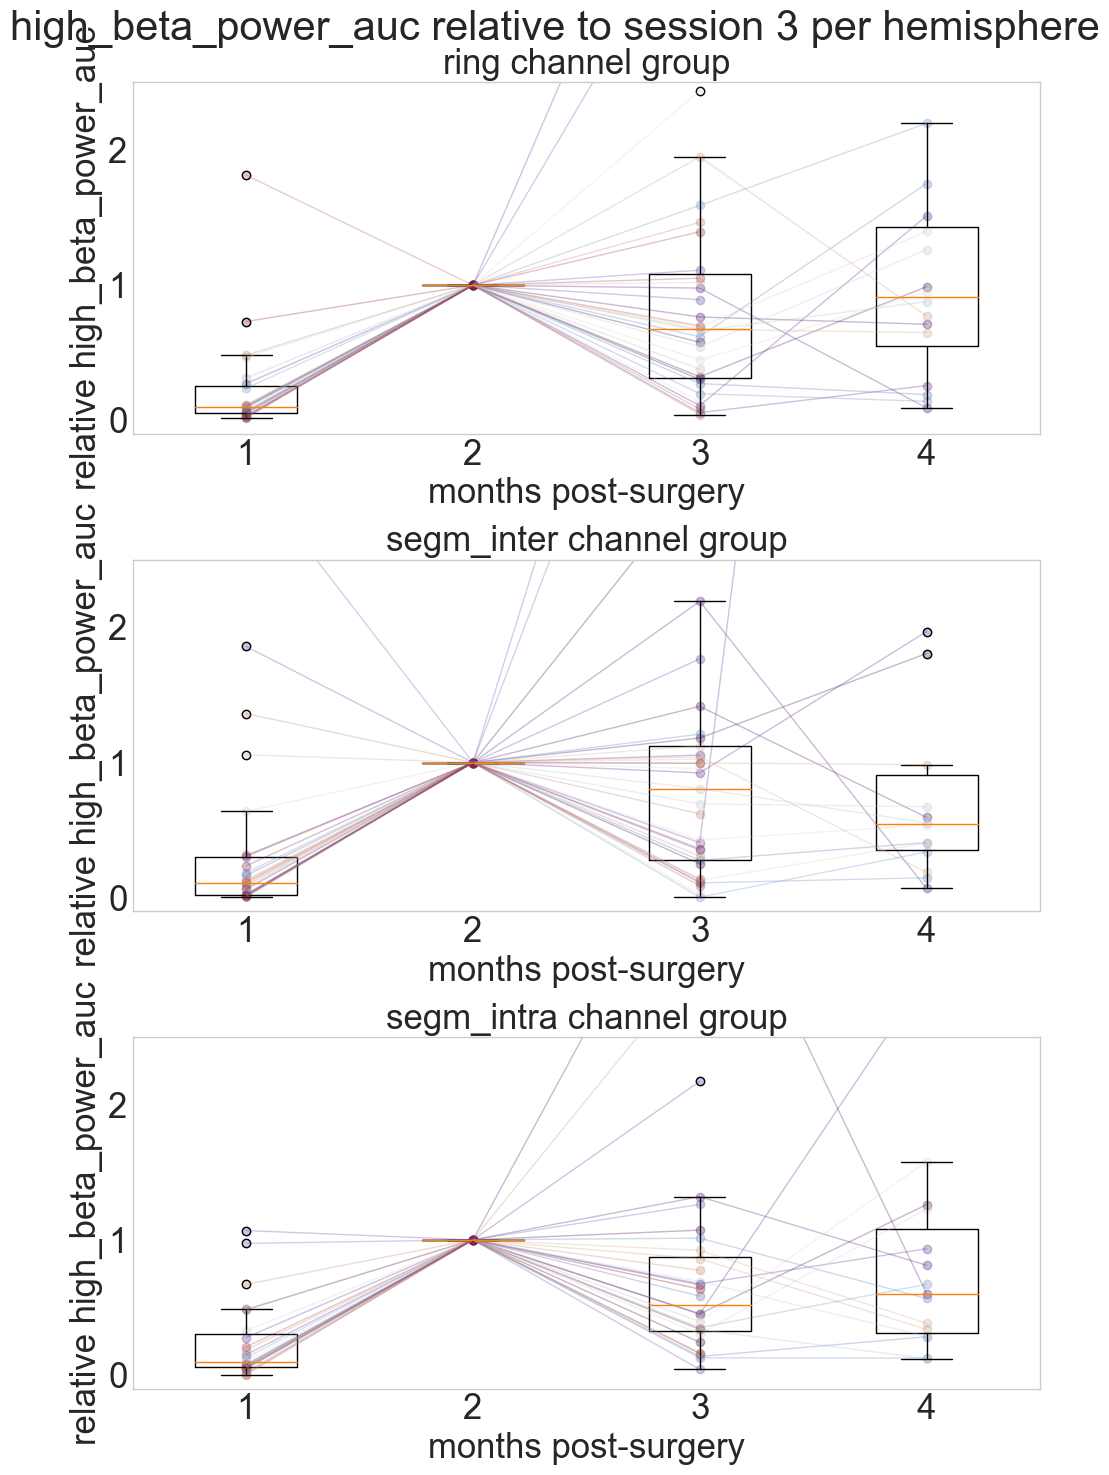

In [18]:
plot_rel_fu3m = fooof_peaks.plot_rel_to_fu3m_cf_or_power(
    fooof_spectrum="periodic_spectrum",
    fooof_version="v2",
    data_to_analyze="high_beta_power_auc",
    around_cf="around_cf_at_each_session",
    percentage="yes"

)

In [10]:
description_data = fooof_peaks.get_description_of_data(
    fooof_spectrum="periodic_spectrum",
    fooof_version="v2",
    data_to_analyze="high_beta_power_auc",
    around_cf="around_cf_at_fixed_session",
    percentage="yes"
)


The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate

In [11]:
description_data["description"]

,data_info,sample_size,mean,std,median,outliers_indices,outliers_values,n_outliers,min,max,25%,50%,75%,shapiro_wilk_stat,shapiro_wilk_p,normal_distribution,group,session
0,high_beta_power_auc,23,0.172491,0.207669,0.095684,"Index([62, 89, 110], dtype='int64')","[0.51329977600512, 0.5572818937487942, 0.83448...",3,0.000001,0.834486,0.039188,0.095684,0.208904,0.761952,1.000776e-04,False,ring,0
1,high_beta_power_auc,31,0.854315,0.900199,0.683363,"Index([22], dtype='int64')",[4.881367898216476],1,0.022658,4.881368,0.266836,0.683363,1.107786,0.705252,1.390490e-06,False,ring,12
2,high_beta_power_auc,16,0.986511,1.168202,0.673268,"Index([23], dtype='int64')",[5.193727724297378],1,0.092992,5.193728,0.427617,0.673268,1.020948,0.613859,2.193982e-05,False,ring,18
3,high_beta_power_auc,25,0.304882,0.574932,0.084880,"Index([139, 147, 177, 204], dtype='int64')","[1.459149360231287, 2.2179541827104394, 0.5154...",4,0.000562,2.217954,0.014941,0.084880,0.192820,0.564062,1.707530e-07,False,segm_inter,0
4,high_beta_power_auc,33,0.927410,1.353119,0.480774,"Index([119, 146], dtype='int64')","[3.1031677867548235, 7.6343463962562685]",2,0.004638,7.634346,0.170616,0.480774,1.097534,0.558295,8.330852e-09,False,segm_inter,12
5,high_beta_power_auc,14,0.682126,0.610281,0.441937,"Index([122, 138], dtype='int64')","[2.122140926565681, 1.8773518532459814]",2,0.021664,2.122141,0.307570,0.441937,0.932695,0.824205,1.010292e-02,False,segm_inter,18
6,high_beta_power_auc,23,0.260413,0.341596,0.086125,"Index([256, 264], dtype='int64')","[1.0295004674994486, 1.2196334272541083]",2,0.000070,1.219633,0.040018,0.086125,0.356224,0.737074,4.409973e-05,False,segm_intra,0
7,high_beta_power_auc,32,0.785717,0.830986,0.649922,"Index([241, 263], dtype='int64')","[4.095565508759199, 3.2399021942842667]",2,0.041708,4.095566,0.321786,0.649922,0.883169,0.679361,4.332335e-07,False,segm_intra,12
8,high_beta_power_auc,15,0.659587,0.472787,0.440392,"Index([305], dtype='int64')",[1.8124677813579675],1,0.125317,1.812468,0.361181,0.440392,0.854986,0.863247,2.688991e-02,False,segm_intra,18


In [12]:
description_data["STN_list"]

,group,session,stn_list,sample_size
0,ring,0,"[024_Right, 024_Left, 025_Right, 029_Right, 02...",23
1,ring,3,"[017_Right, 017_Left, 019_Right, 019_Left, 021...",46
2,ring,12,"[017_Right, 017_Left, 019_Right, 019_Left, 021...",31
3,ring,18,"[019_Right, 019_Left, 021_Right, 021_Left, 024...",16
4,segm_inter,0,"[024_Right, 024_Left, 025_Right, 026_Right, 02...",25
5,segm_inter,3,"[017_Right, 017_Left, 019_Right, 019_Left, 021...",45
6,segm_inter,12,"[017_Right, 017_Left, 019_Right, 019_Left, 021...",33
7,segm_inter,18,"[019_Right, 019_Left, 021_Right, 021_Left, 024...",14
8,segm_intra,0,"[024_Right, 024_Left, 025_Right, 026_Right, 02...",23
9,segm_intra,3,"[017_Right, 017_Left, 019_Right, 019_Left, 021...",45


In [13]:
description_data["statistics_MWU"]

,group,pair,statistic_mwu,pval
0,ring,"(0, 3)",0.0,0.0000
1,ring,"(0, 12)",97.0,0.0000
2,ring,"(0, 18)",38.0,0.0000
3,ring,"(3, 12)",1012.0,0.0005
4,ring,"(3, 18)",552.0,0.0001
5,ring,"(12, 18)",239.0,0.8487
6,segm_inter,"(0, 3)",135.0,0.0000
7,segm_inter,"(0, 12)",162.0,0.0001
8,segm_inter,"(0, 18)",72.0,0.0027
9,segm_inter,"(3, 12)",900.0,0.0773
